0.9773306039920846

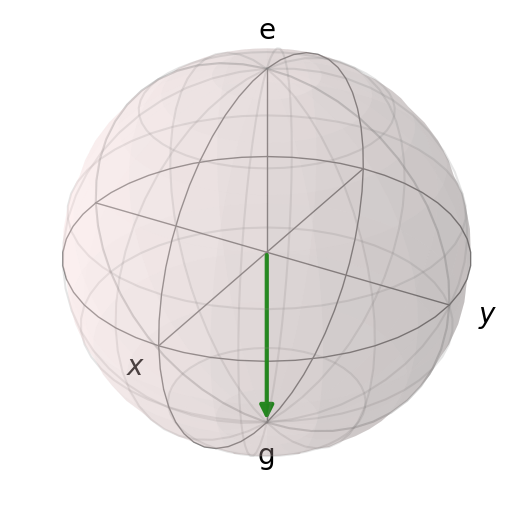

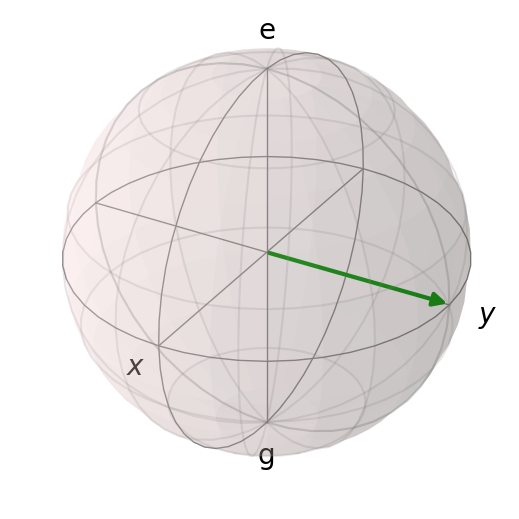

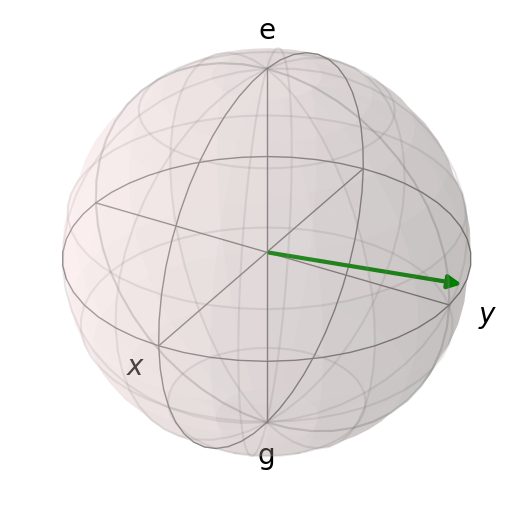

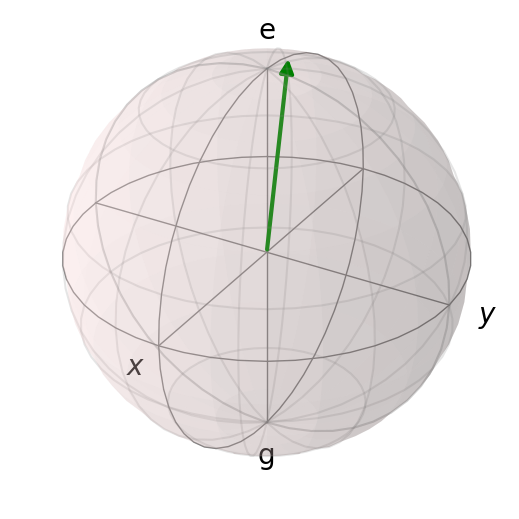

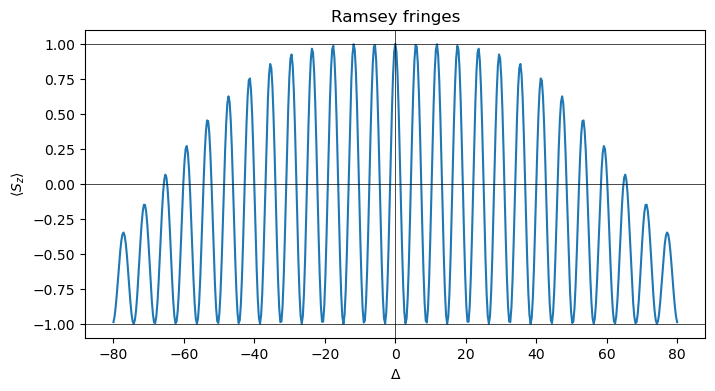

In [8]:
using QuantumOptics
using PyPlot: matplotlib

using PyCall
qutip = pyimport("qutip");

N = 2 # Atom number
γ = 0.0# 0.1 # Decay rate
Δ = 0.2#0.05 # Detuning
η = 15.0 # Pulse strength

T = π/4η # Length for pulse
Tsteps = 101
Tlist = collect(range(0, stop=T, length=Tsteps))

τ = γ == 0 ? 1.0 : 0.5/γ # Length of free time evolution; 1.0 if γ=0, else 0.5/γ
τsteps = 201
τlist = collect(range(0, stop=τ, length=τsteps))

b_atom = SpinBasis(1//2)
b_coll = tensor([b_atom for i=1:N]...);

# Single atom operators
sm(i) = embed(b_coll, i, sigmam(b_atom))
sp(i) = embed(b_coll, i, sigmap(b_atom))
sz(i) = embed(b_coll, i, sigmaz(b_atom))

# Collective operators
Sx = 0.5*sum(sm.(1:N) + sp.(1:N))
Sy = 0.5im*sum(sm.(1:N) - sp.(1:N))
Sz = 0.5*sum(sz.(1:N));

H_at = Δ*Sz;

H_l = 2η*Sx;

J = [sm(i) for i=1:N]
rates = [γ for i=1:N];

ψ₀ = tensor([spindown(b_atom) for i=1:N]...);

bloch(ρ) = [real(expect(s, ρ)) for s=[Sx, Sy, Sz]];

function show_bloch(bloch)
    b = qutip.Bloch()
    b.add_vectors(bloch)
    b.zlabel = ["e", "g"]
    b.view = [-60, 30]
    b.render()
end

bloch0 = bloch(ψ₀)

show_bloch(bloch0)

H_at.data

H_l.data

ψ₀

Tout, ρT = timeevolution.master(Tlist, ψ₀, H_at + H_l, J; rates=rates)

inv_π2 = sum([real(expect(sz(i), ρT)) for i=1:N])
ρπ2 = ρT[end]; # State after first π/2-pulse

bloch_π2 = bloch(ρπ2)

norm(bloch_π2)

show_bloch(bloch_π2)

τout, ρτ = timeevolution.master(τlist, ρπ2, H_at, J; rates=rates);

ρm = ρτ[end]; # State after free time evolution

bloch_m = bloch(ρm)

show_bloch(bloch_m)

Tout, ρT = timeevolution.master(Tlist, ρm, H_at + H_l, J; rates=rates)
ρπ = ρT[end]; # Final state after second π/2-pulse

bloch_π = bloch(ρπ)

show_bloch(bloch_π)

print(bloch_π[3])

function ramsey(Δ)
    H_at = Δ*Sz
    Tout, ρ1 = timeevolution.master(Tlist, ψ₀, H_at + H_l, J; rates=rates) # First π/2-pulse
    τout, ρτ = timeevolution.master(τlist, ρ1[end], H_at, J; rates=rates) # Free time evolution
    Tout, ρ2 = timeevolution.master(Tlist, ρτ[end], H_at + H_l, J; rates=rates) # Second π/2-pulse
    real(expect(Sz, ρ2[end])) # Return resulting final inversion
end;

Δ_ls = collect(range(-80, stop=80, length=501)) # List of detunings
Sz_exp = ramsey.(Δ_ls);

function show_ramsey_fringes(Δ_ls, Sz_exp)
    fig, ax = matplotlib.pyplot.subplots(figsize = (8, 4))
    ax.plot(Δ_ls, Sz_exp)
    for y in (-1, 0, 1)
        ax.axhline(y, color="black", lw=0.5)
    end
    ax.axvline(0, color="black", lw=0.5)
    ax.set_ylabel(raw"$\langle S_z\rangle$")
    ax.set_xlabel(raw"$\Delta$")
    ax.set_title("Ramsey fringes");
end;

show_ramsey_fringes(Δ_ls, Sz_exp);

In [7]:
import Pkg; Pkg.add("PyCall")

   Resolving package versions...
    Updating `/opt/julia/environments/v1.9/Project.toml`
  [438e738f] + PyCall v1.96.4
  No Changes to `/opt/julia/environments/v1.9/Manifest.toml`
